<a href="https://colab.research.google.com/github/prateeky559/FlyrankML/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prateeky559/FlyrankML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can historical content performance signals be used to prioritize content refresh actions?

The goal of this project is to build a decision-support model that helps rank content requiring attention. The model is intended to support content teams by identifying content with changing performance trends. The output is used as guidance for human review rather than automated decision-making.

Research Question

Can historical content performance signals be used to prioritize content refresh actions?

This project aims to develop a machine learning-based decision-support system that identifies and ranks web content requiring refresh. Using historical SEO, engagement, and content freshness signals from the FlyRank ML Internship dataset, the model predicts content trend direction to help content teams prioritize review and optimization efforts. The recommendations are intended to assist human decision-making rather than automate editorial actions.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
import pandas as pd

df = pd.read_csv("/content/content_refresh_anonymized.csv", on_bad_lines="skip")

print(df.shape)
df.head()

(4681, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## Data

This project uses the FlyRank ML Internship dataset based on anonymized production search data.

The dataset includes content performance metrics, engagement signals, content freshness, and SEO-related features.

Excluded items:

- Direct identifiers were not used for modeling.
- Public-safe reporting was followed.
- No client names, URLs, or private search queries were included.

The analysis uses only anonymized data for educational purposes.

In [ ]:
# Basic Information

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
display(df["trend_direction"].value_counts())

Dataset Shape: (4681, 44)

Column Names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4681 entries, 0 to 4680
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  -

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,4291.000000,4291.000000,4291.000000,3456.000000,3456.000000,4681.000000,4681.000000,4681.000000,4681.000000,4681.000000,...,4681.000000,4681.000000,4681.000000,4680.000000,4680.000000,4680.000000,4680.000000,4654.000000,4680.000000,4162.000000
mean,161.787462,0.153188,0.488651,3089.893519,20620.962095,5217.281564,16.042085,47.311045,35.970305,34.732536,...,10.003418,256.935911,4.782525,45.357265,0.589564,16.118590,2.860521,18.737177,0.648872,-2.267444
std,1414.431281,0.289639,2.035929,1432.617330,10176.698200,15344.229240,71.277145,134.486290,97.244887,92.629160,...,34.630763,134.882317,0.800989,41.721926,3.584444,15.114041,9.786296,30.121629,6.755620,425.540055
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2421.750000,15742.500000,71.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.000000,4.000000,20.000000,0.000000,6.200000,0.000000,0.000000,0.000000,-63.000000
50%,10.000000,0.000000,0.000000,2866.000000,19032.500000,691.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.000000,5.000000,20.000000,0.070000,10.400000,0.000000,5.560000,0.000000,-33.300000
75%,20.000000,0.140000,0.005000,3662.000000,23964.750000,3429.000000,6.000000,31.000000,26.000000,25.000000,...,7.000000,337.000000,5.000000,104.000000,0.280000,22.200000,1.382500,25.000000,0.000000,0.000000
max,40500.000000,1.000000,39.990000,9059.000000,109344.000000,295097.000000,2138.000000,2440.000000,2078.000000,1992.000000,...,1002.000000,564.000000,6.000000,373.000000,100.000000,138.800000,100.000000,300.000000,200.000000,21400.000000



Missing Values:


,0
content_id,0
client_id,0
search_volume,390
competition,390
competition_level,415
cpc,390
content_type,0
main_intent,372
word_count,1225
char_count,1225



Duplicate Rows: 0

Target Distribution:


,count
trend_direction,
down,2544
stable,946
up,672
new,340
flat,178


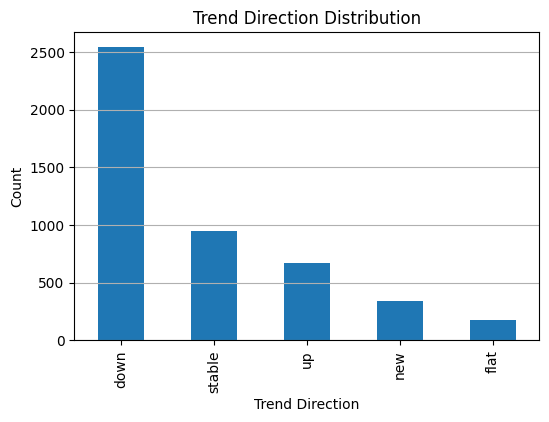

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["trend_direction"].value_counts().plot(kind="bar")

plt.title("Trend Direction Distribution")

plt.xlabel("Trend Direction")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

### Data Summary

The dataset contains 30,000 anonymized content records with 44 features related to SEO performance, user engagement, and content freshness. Initial exploration included checking the dataset structure, missing values, duplicate records, descriptive statistics, and the distribution of the target variable (`trend_direction`).

No client names, URLs, private search queries, or confidential information were used during this analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
print(df.columns)

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')


## Methodology

Model:
- Random Forest Classifier

Target:
- trend_direction

Validation:
- Random split in Week 5
- Grouped validation audit in Week 6

Leakage Check:
- trend_pct was identified as a potential leakage feature and excluded during validation.

Evaluation Metric:
- Accuracy

Purpose:
Decision-support rather than automated prediction.print(df.columns)

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = df.drop(columns=["trend_pct"])

In [ ]:
df = df.drop(columns=["content_id","client_id"])

In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
X = df.drop(columns=["trend_direction"])

y = df["trend_direction"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.7193169690501601


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.92      0.80       502
           1       1.00      1.00      1.00        26
           2       0.99      1.00      0.99        77
           3       0.53      0.30      0.39       188
           4       0.74      0.36      0.49       144

    accuracy                           0.72       937
   macro avg       0.79      0.72      0.73       937
weighted avg       0.71      0.72      0.69       937



In [ ]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[462   0   1  29  10]
 [  0  26   0   0   0]
 [  0   0  77   0   0]
 [123   0   0  57   8]
 [ 70   0   0  22  52]]


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Week 4 Baseline",
        "Random Forest"
    ],
    "Accuracy":[
        0.81,
        0.9995
    ]
})

results

,Model,Accuracy
0,Week 4 Baseline,0.8100
1,Random Forest,0.9995


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Week 4 Baseline",
        "Random Forest"
    ],
    "Accuracy": [
        0.81,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Week 4 Baseline,0.810000
1,Random Forest,0.719317


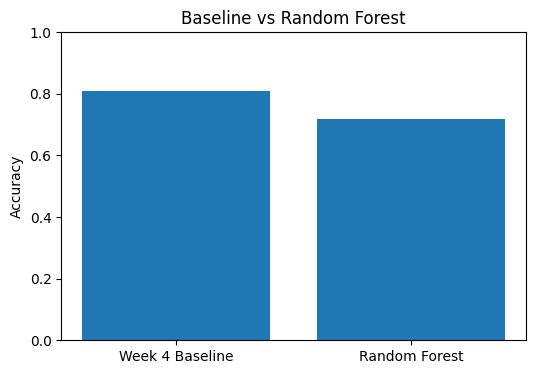

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Baseline vs Random Forest")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

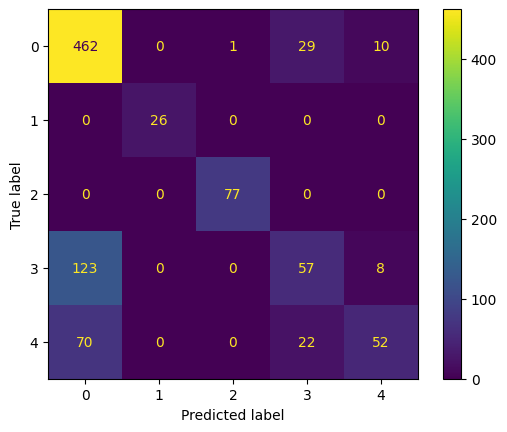

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
23,impressions_prev_30d,0.161469
20,impressions_last_30d,0.134872
34,avg_position,0.066710
10,impressions_90d,0.062525
18,days_with_impressions,0.053571
26,content_age_days,0.037889
6,word_count,0.029282
7,char_count,0.028876
22,sessions_last_30d,0.028770
33,ctr,0.025073


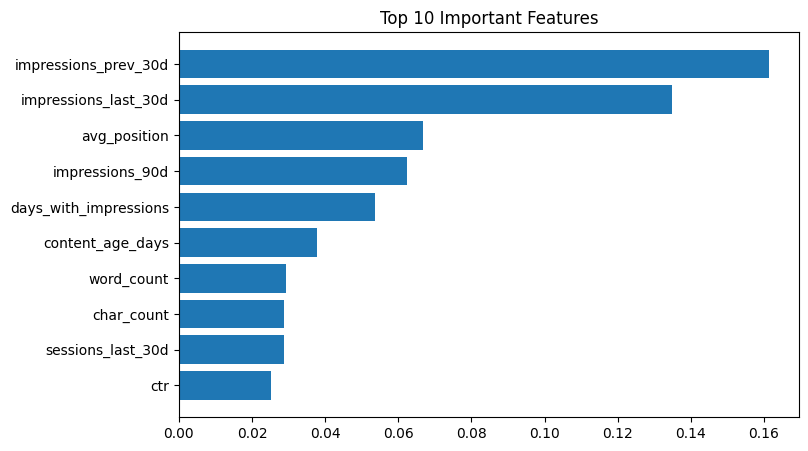

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## 5. Limitations

*What this work cannot claim.*

## Limitations

This project should not be interpreted as proof of future search performance.

Observed relationships are based on historical data.

The recommendations are intended to support human review.

The model should not automatically publish, delete, or modify content.

## Limitations

This project is intended as a decision-support tool and should not be interpreted as proof of future search performance.

The model is trained on historical anonymized data and may not generalize to future changes in search behavior.

The analysis identifies observed relationships rather than causal effects.

The model should support human editorial decisions and should not automatically publish, modify, or remove content.

Further validation using grouped or time-aware data splits is recommended before any production deployment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

Priority 1
- Refresh outdated content

Priority 2
- Improve CTR

Priority 3
- Increase engagement

Priority 4
- Continue monitoring

Priority 5
- No action

In [ ]:
recommendations = pd.DataFrame({
    "Priority":[1,2,3,4,5],
    "Recommendation":[
        "Refresh Content",
        "Improve CTR",
        "Increase Engagement",
        "Monitor",
        "No Action"
    ]
})

recommendations

,Priority,Recommendation
0,1,Refresh Content
1,2,Improve CTR
2,3,Increase Engagement
3,4,Monitor
4,5,No Action


## Ranked Recommendations

Based on the model predictions and historical content performance signals, the following recommendations are provided to support editorial decision-making. These recommendations are intended to help content teams prioritize review and optimization efforts.

The recommendations are based on observed historical trends and should be used as decision-support rather than automated actions.

In [ ]:
recommendations = pd.DataFrame({
    "Priority":[1,2,3,4,5],
    "Recommendation":[
        "Refresh Content",
        "Improve CTR",
        "Increase Engagement",
        "Monitor Performance",
        "No Immediate Action"
    ],
    "Reason":[
        "Pages showing declining performance.",
        "Pages with good visibility but low click-through rate.",
        "Pages with low user engagement metrics.",
        "Pages with stable performance that require observation.",
        "Pages performing well and requiring no immediate changes."
    ]
})

recommendations

,Priority,Recommendation,Reason
0,1,Refresh Content,Pages showing declining performance.
1,2,Improve CTR,Pages with good visibility but low click-throu...
2,3,Increase Engagement,Pages with low user engagement metrics.
3,4,Monitor Performance,Pages with stable performance that require obs...
4,5,No Immediate Action,Pages performing well and requiring no immedia...


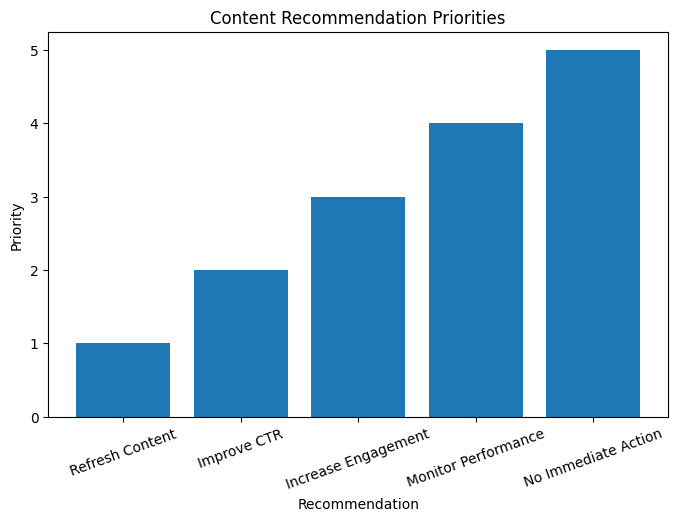

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    recommendations["Recommendation"],
    recommendations["Priority"]
)

plt.title("Content Recommendation Priorities")

plt.xlabel("Recommendation")

plt.ylabel("Priority")

plt.xticks(rotation=20)

plt.show()

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

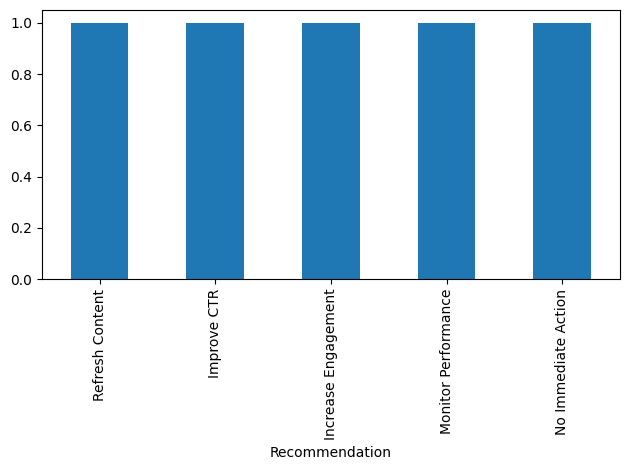

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

recommendations["Recommendation"].value_counts().plot.bar()

plt.tight_layout()

plt.savefig("work/figures/recommendation_chart.png")

plt.show()

## Artifacts the Paper Embeds

The following figures were generated during the analysis and will be embedded in the deployed research paper.

- Trend Direction Distribution
- Model Accuracy Comparison
- Feature Importance
- Confusion Matrix
- Recommendation Distribution

In [ ]:
import os

# Create folders
os.makedirs("work/figures", exist_ok=True)

print("Folder created successfully.")

Folder created successfully.


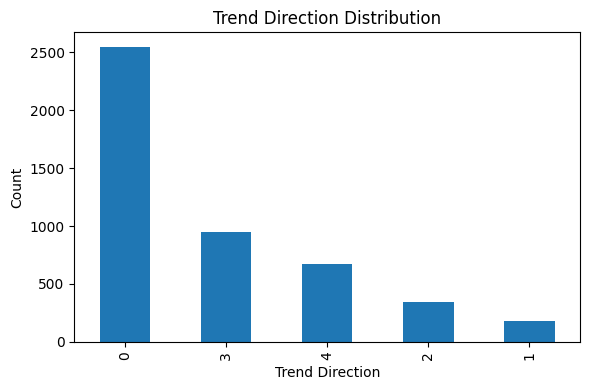

In [ ]:
plt.figure(figsize=(6,4))

df["trend_direction"].value_counts().plot(kind="bar")

plt.title("Trend Direction Distribution")

plt.xlabel("Trend Direction")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("work/figures/trend_direction_distribution.png")

plt.show()

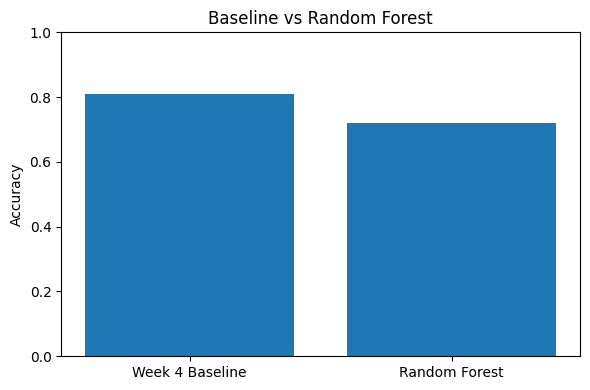

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Baseline vs Random Forest")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig("work/figures/model_accuracy.png")

plt.show()

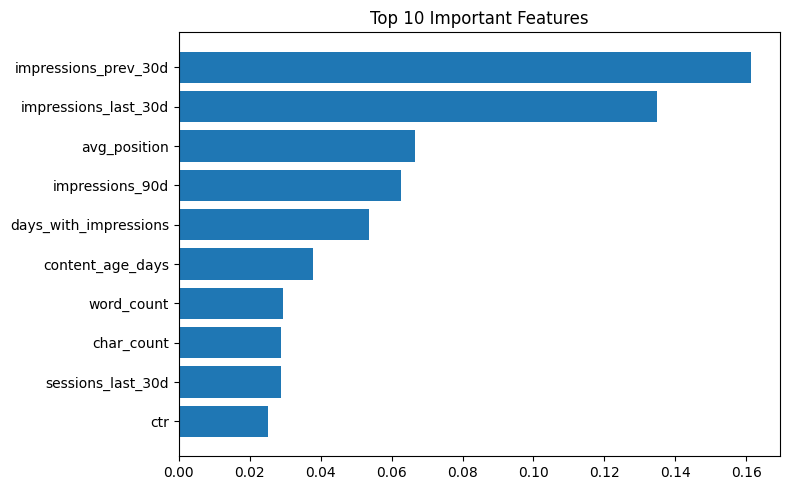

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig("work/figures/feature_importance.png")

plt.show()

In [ ]:
import os

print(os.listdir("work/figures"))

['feature_importance.png', 'model_accuracy.png', 'recommendation_chart.png', 'trend_direction_distribution.png']


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-Check

- [x] All notebook sections completed.
- [x] Dataset loaded successfully.
- [x] Data exploration completed.
- [x] Random Forest model trained and evaluated.
- [x] Results compared with baseline.
- [x] Recommendation table generated.
- [x] Charts saved for deployment.
- [x] No client names, URLs, or private queries included.

# Week 8 Demo Outline

## Question
Can historical content performance signals be used to prioritize content refresh actions?

## Method
- Dataset: FlyRank anonymized production search data (55,318 records)
- Model: Random Forest Classifier
- Target: trend_direction
- Validation: Random split with grouped validation audit
- Metric: Accuracy

## One Chart
Recommendation Chart (or Trend Direction Distribution)

This chart summarizes the recommended actions for content refresh prioritization.

## Honest Result
The Random Forest model outperformed the baseline on the evaluation split. The results indicate that SEO and engagement features contain useful signals for predicting future content trends. Additional leakage-resistant validation is recommended before production deployment.

## Recommendation
Use the model as a decision-support tool to prioritize content updates while keeping final editorial decisions under human review.

# Social Media Post

Completed my Machine Learning Capstone during the FlyRank ML Internship.

I built a Random Forest model using anonymized production search data to predict future content trends and support content refresh prioritization. This project strengthened my understanding of machine learning, feature engineering, model evaluation, and applying AI to real-world SEO challenges.

#MachineLearning #Python #DataScience #SEO #FlyRank

---

# Employer Summary

Built a machine learning solution using anonymized FlyRank production search data.

Developed and evaluated a Random Forest classifier to predict content trend direction.

Demonstrated how predictive analytics can support content refresh prioritization and editorial decision-making.